In [90]:
import pandas as pd

fake = pd.read_csv(
    "/content/Fake.csv",
    engine="python",
    on_bad_lines="skip"
)

true = pd.read_csv(
    "/content/True.csv",
    engine="python",
    on_bad_lines="skip"
)

print("Fake dataset:", fake.shape)
print("True dataset:", true.shape)

Fake dataset: (4621, 4)
True dataset: (4532, 4)


In [91]:
import os

print("Current location:", os.getcwd())
print("Files available:")
print(os.listdir("/"))

Current location: /content
Files available:
['bin', 'home', 'media', 'usr', 'etc', 'tmp', 'sys', 'proc', 'mnt', 'dev', 'sbin', 'lib', 'root', 'lib64', 'boot', 'srv', 'opt', 'var', 'libx32', 'lib32', 'run', 'kaggle', 'content', '.dockerenv', 'tools', 'datalab', 'python-apt', 'python-apt.tar.xz']


In [92]:
print("FAKE NEWS DATA")
display(fake.head())

print("\nREAL NEWS DATA")
display(true.head())

FAKE NEWS DATA


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"



REAL NEWS DATA


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [93]:
print("Fake dataset columns:")
print(fake.columns.tolist())

print("\nReal dataset columns:")
print(true.columns.tolist())

Fake dataset columns:
['title', 'text', 'subject', 'date']

Real dataset columns:
['title', 'text', 'subject', 'date']


In [94]:
# Add labels to each dataset

fake["label"] = 0
true["label"] = 1

print("Fake news label:", fake["label"].unique())
print("Real news label:", true["label"].unique())

Fake news label: [0]
Real news label: [1]


In [95]:
# Combine fake and real news

data = pd.concat([fake, true], ignore_index=True)

print("Combined dataset shape:", data.shape)

Combined dataset shape: (9153, 5)


In [96]:
# Check for missing values

print(data.isnull().sum())

title      0
text       1
subject    1
date       1
label      0
dtype: int64


In [97]:
# Check for duplicate rows

print("Number of duplicate rows:", data.duplicated().sum())

Number of duplicate rows: 30


In [98]:
# Remove duplicate rows

data = data.drop_duplicates()

print("Dataset shape after removing duplicates:", data.shape)

Dataset shape after removing duplicates: (9123, 5)


In [99]:
print(data.isnull().sum())

title      0
text       1
subject    1
date       1
label      0
dtype: int64


In [100]:
import re

In [101]:
def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [102]:
sample_text = data['text'].iloc[0]

print("ORIGINAL TEXT:")
print(sample_text[:500])

print("\n" + "="*80 + "\n")

print("CLEANED TEXT:")
print(clean_text(sample_text[:500]))

ORIGINAL TEXT:
Donald Trump just couldn t wish all Americans a Happy New Year and leave it at that. Instead, he had to give a shout out to his enemies, haters and  the very dishonest fake news media.  The former reality show star had just one job to do and he couldn t do it. As our Country rapidly grows stronger and smarter, I want to wish all of my friends, supporters, enemies, haters, and even the very dishonest Fake News Media, a Happy and Healthy New Year,  President Angry Pants tweeted.  2018 will be a gr


CLEANED TEXT:
donald trump just couldn t wish all americans a happy new year and leave it at that instead he had to give a shout out to his enemies haters and the very dishonest fake news media the former reality show star had just one job to do and he couldn t do it as our country rapidly grows stronger and smarter i want to wish all of my friends supporters enemies haters and even the very dishonest fake news media a happy and healthy new year president angry pants tweeted wi

In [103]:
data['clean_text'] = data['text'].apply(clean_text)

print("Text cleaning completed!")

Text cleaning completed!


In [104]:
import nltk

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [105]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

print("Total stopwords:", len(stop_words))
print("First 10 stopwords:", list(stop_words)[:10])

Total stopwords: 198
First 10 stopwords: ["they'd", "we'd", 'after', 'am', 'into', "we're", "didn't", 'themselves', 'him', 'do']


In [106]:
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return " ".join(filtered_words)

In [107]:
sample_cleaned = data['clean_text'].iloc[0]

print("BEFORE STOPWORD REMOVAL:")
print(sample_cleaned[:500])

print("\n" + "="*80 + "\n")

print("AFTER STOPWORD REMOVAL:")
print(remove_stopwords(sample_cleaned[:500]))

BEFORE STOPWORD REMOVAL:
donald trump just couldn t wish all americans a happy new year and leave it at that instead he had to give a shout out to his enemies haters and the very dishonest fake news media the former reality show star had just one job to do and he couldn t do it as our country rapidly grows stronger and smarter i want to wish all of my friends supporters enemies haters and even the very dishonest fake news media a happy and healthy new year president angry pants tweeted will be a great year for america a


AFTER STOPWORD REMOVAL:
donald trump wish americans happy new year leave instead give shout enemies haters dishonest fake news media former reality show star one job country rapidly grows stronger smarter want wish friends supporters enemies haters even dishonest fake news media happy healthy new year president angry pants tweeted great year america


In [108]:
data['final_text'] = data['clean_text'].apply(remove_stopwords)

print("Stopword removal completed!")

Stopword removal completed!


In [109]:
data[['clean_text', 'final_text']].head()

,clean_text,final_text
0,donald trump just couldn t wish all americans ...,donald trump wish americans happy new year lea...
1,house intelligence committee chairman devin nu...,house intelligence committee chairman devin nu...
2,on friday it was revealed that former milwauke...,friday revealed former milwaukee sheriff david...
3,on christmas day donald trump announced that h...,christmas day donald trump announced would bac...
4,pope francis used his annual christmas day mes...,pope francis used annual christmas day message...


In [110]:
X = data['final_text']
y = data['label']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (9123,)
y shape: (9123,)


In [111]:
from sklearn.model_selection import train_test_split

In [112]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (7298,)
Testing data: (1825,)


In [113]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [114]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2
)

In [115]:
print("TF-IDF vectorizer created successfully!")

TF-IDF vectorizer created successfully!


In [116]:
X_train_tfidf = tfidf.fit_transform(X_train)

print("Training TF-IDF shape:", X_train_tfidf.shape)

Training TF-IDF shape: (7298, 50000)


In [117]:
tfidf.fit_transform(X_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1598153 stored elements and shape (7298, 50000)>

In [118]:
tfidf.transform(X_test)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 392604 stored elements and shape (1825, 50000)>

In [119]:
X_train_tfidf = tfidf.fit_transform(X_train)
print("Training TF-IDF shape:", X_train_tfidf.shape)


Training TF-IDF shape: (7298, 50000)


In [120]:
X_test_tfidf = tfidf.transform(X_test)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Testing TF-IDF shape: (1825, 50000)


In [121]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [122]:
from sklearn.linear_model import LogisticRegression

In [123]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [124]:
y_pred = model.predict(X_test_tfidf)

print("Predictions completed!")
print("Number of predictions:", len(y_pred))

Predictions completed!
Number of predictions: 1825


In [125]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy percentage:", accuracy * 100, "%")

Accuracy: 0.9928767123287672
Accuracy percentage: 99.28767123287672 %


In [126]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Fake", "Real"]
))

              precision    recall  f1-score   support

        Fake       1.00      0.99      0.99       924
        Real       0.99      1.00      0.99       901

    accuracy                           0.99      1825
   macro avg       0.99      0.99      0.99      1825
weighted avg       0.99      0.99      0.99      1825



In [127]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[915   9]
 [  4 897]]


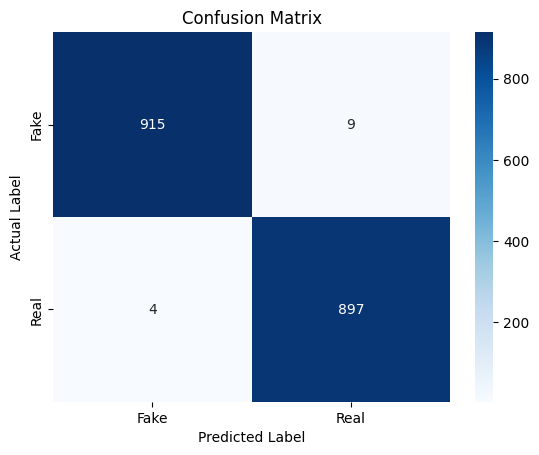

In [128]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

In [129]:
# Find TF-IDF/vectorizer variables already created in the notebook
[x for x in globals() if 'tfidf' in x.lower() or 'vector' in x.lower()]

['TfidfVectorizer', 'tfidf', 'X_train_tfidf', 'X_test_tfidf', 'news_tfidf']

In [130]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [131]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [132]:
y_pred = model.predict(X_test_tfidf)

In [133]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9912328767123287

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       924
           1       0.99      0.99      0.99       901

    accuracy                           0.99      1825
   macro avg       0.99      0.99      0.99      1825
weighted avg       0.99      0.99      0.99      1825



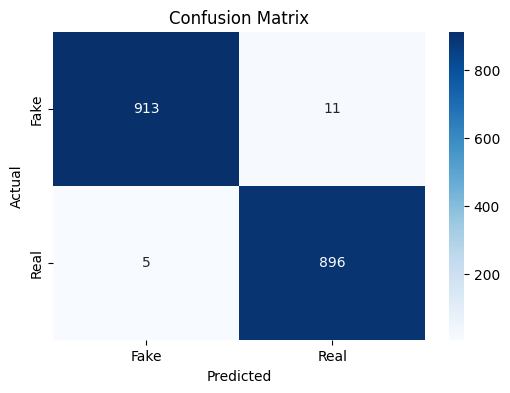

In [134]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [135]:
y_prob = model.predict_proba(X_test_tfidf)[:, 1]

In [136]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.999257679057901


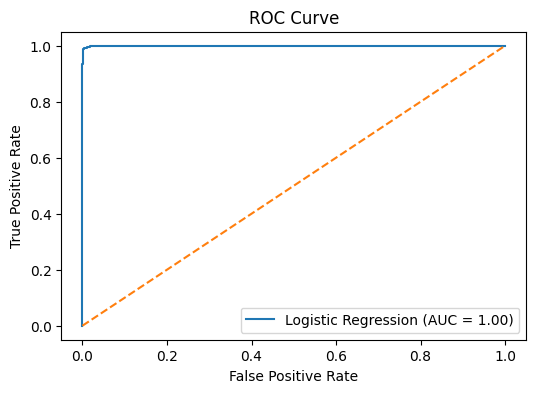

In [137]:
plt.figure(figsize=(6, 4))

plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [138]:
news = input("Enter a news article: ")

news_tfidf = tfidf.transform([news])

prediction = model.predict(news_tfidf)

print("Prediction:", prediction[0])

Enter a news article: "hello"
Prediction: 0


In [139]:
probability = model.predict_proba(news_tfidf)

print("Prediction:", prediction[0])
print("Fake Probability:", probability[0][0])
print("Real Probability:", probability[0][1])

Prediction: 0
Fake Probability: 0.6837697098182984
Real Probability: 0.3162302901817015


In [140]:
import joblib

joblib.dump(model, "fake_news_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [141]:
model = joblib.load("fake_news_model.pkl")
tfidf = joblib.load("tfidf_vectorizer.pkl")

In [142]:
news = input("Enter a news article: ")

Enter a news article: "hello"


In [143]:
news_tfidf = tfidf.transform([news])


In [144]:
prediction = model.predict(news_tfidf)

print("Prediction:", prediction[0])

Prediction: 0


In [145]:
probability = model.predict_proba(news_tfidf)

print("Prediction:", prediction[0])
print("Fake Probability:", probability[0][0])
print("Real Probability:", probability[0][1])

Prediction: 0
Fake Probability: 0.6837697098182984
Real Probability: 0.3162302901817015


In [146]:
import joblib

model = joblib.load("fake_news_model.pkl")
tfidf = joblib.load("tfidf_vectorizer.pkl")

news = input("Enter a news article: ")

news_tfidf = tfidf.transform([news])

prediction = model.predict(news_tfidf)
probability = model.predict_proba(news_tfidf)

print("\nPrediction:", prediction[0])
print("Fake Probability:", probability[0][0])
print("Real Probability:", probability[0][1])

Enter a news article: "heeeeeeeeeeeeelllllllllllllllllloooooooooooooooooo"

Prediction: 0
Fake Probability: 0.6739881873670726
Real Probability: 0.3260118126329275


In [147]:
print(y_train.unique())

[0 1]


In [148]:
print(type(y_train))

<class 'pandas.core.series.Series'>


In [149]:
print(y_train[:10])


3677    0
598     0
2290    0
4921    1
3774    0
6262    1
4468    0
5411    1
3494    0
1621    0
Name: label, dtype: int64


After running the above cell, you'll be prompted to authorize Colab to access your Google Drive. Once authorized, your Drive will be mounted at `/content/drive`.

In [150]:
news = input("Enter a news article: ")

news_tfidf = tfidf.transform([news])

prediction = model.predict(news_tfidf)

print("Prediction:", prediction[0])

Enter a news article: "hhhhiiiiiii"
Prediction: 0
